In [2]:
import numpy as np              
import pandas as pd             
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [3]:
df=pd.read_csv('numbeo_cost_of_living.csv')
print(df.head())
print(df.info())
print(df.describe())
print(df.shape)
print(df.isnull().sum())
print(df.columns)

        city  monthly_cost_family_of_four  monthly_cost_single_person  \
0     Mumbai                     131960.1                     36750.7   
1      Delhi                     126230.6                     35014.1   
2  Bangalore                     118885.0                     32536.6   
3  Hyderabad                     113989.5                     31655.3   
4  Ahmedabad                     114216.0                     32099.5   

   meal at an inexpensive restaurant  \
0                              500.0   
1                              500.0   
2                              250.0   
3                              250.0   
4                              300.0   

   meal for two at a mid-range restaurant (three courses, without drinks)  \
0                                             2000.0                        
1                                             2250.0                        
2                                             1500.0                        
3           

In [4]:
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(r"[()]", "", regex=True)
              .str.replace(r"[^a-zA-Z0-9_]", "_", regex=True)
              .str.replace(r"__+", "_", regex=True)
)

df["market_basket_index"] = (
    df["milk_regular_1_liter"] +
    df["fresh_white_bread_500_g_loaf"] +
    df["white_rice_1_kg"] +
    df["eggs_12_large_size"] +
    df["chicken_fillets_1_kg"] +
    df["apples_1_kg"] +
    df["bananas_1_kg"] +
    df["oranges_1_kg"] +
    df["tomatoes_1_kg"] +
    df["potatoes_1_kg"] +
    df["onions_1_kg"]
)

df["transportation_cost_index"] = (
    df["one_way_ticket_local_transport"] +
    df["monthly_public_transport_pass_regular_price"] +
    df["taxi_start_standard_tariff"] +
    df["taxi_1_km_standard_tariff"] +
    df["taxi_1_hour_waiting_standard_tariff"] +
    df["gasoline_1_liter"]
)

df["sports_leisure_index"] = (
    df["monthly_fitness_club_membership"] +
    df["tennis_court_rental_1_hour_weekend"] +
    df["cinema_ticket_international_release"]
)

df["childcare_cost_index"] = (
    df["private_full_day_preschool_or_kindergarten_monthly_fee_per_child"] +
    df["international_primary_school_annual_tuition_per_child"] / 12
)

print(df[["city", "market_basket_index", "transportation_cost_index",
          "sports_leisure_index", "childcare_cost_index"]].head())


        city  market_basket_index  transportation_cost_index  \
0     Mumbai              1161.41                     835.21   
1      Delhi              1102.45                    1848.56   
2  Bangalore              1138.64                    1804.41   
3  Hyderabad              1082.84                    1547.44   
4  Ahmedabad              1173.11                    1170.17   

   sports_leisure_index  childcare_cost_index  
0               4086.42          52311.617500  
1               3244.23          22054.920000  
2               2582.54          40522.730833  
3               2892.64          30513.852500  
4               2396.96          15067.102500  


In [5]:
print(df.columns.tolist())


['city', 'monthly_cost_family_of_four', 'monthly_cost_single_person', 'meal_at_an_inexpensive_restaurant', 'meal_for_two_at_a_mid_range_restaurant_three_courses_without_drinks', 'combo_meal_at_mcdonald_s_or_equivalent_fast_food_meal', 'domestic_draft_beer_0_5_liter', 'imported_beer_0_33_liter_bottle', 'cappuccino_regular_size', 'soft_drink_coca_cola_or_pepsi_0_33_liter_bottle', 'bottled_water_0_33_liter', 'milk_regular_1_liter', 'fresh_white_bread_500_g_loaf', 'white_rice_1_kg', 'eggs_12_large_size', 'local_cheese_1_kg', 'chicken_fillets_1_kg', 'buffalo_round_or_equivalent_back_leg_red_meat_1_kg', 'apples_1_kg', 'bananas_1_kg', 'oranges_1_kg', 'tomatoes_1_kg', 'potatoes_1_kg', 'onions_1_kg', 'lettuce_1_head', 'bottled_water_1_5_liter', 'bottle_of_wine_mid_range', 'domestic_beer_0_5_liter_bottle', 'cigarettes_pack_of_20_marlboro', 'one_way_ticket_local_transport', 'monthly_public_transport_pass_regular_price', 'taxi_start_standard_tariff', 'taxi_1_km_standard_tariff', 'taxi_1_hour_waiti

In [6]:
keep_cols = [
    "city",
    # Restaurants
    "meal_at_an_inexpensive_restaurant",
    "meal_for_two_at_a_mid_range_restaurant_three_courses_without_drinks",
    "combo_meal_at_mcdonald_s_or_equivalent_fast_food_meal",
    "cappuccino_regular_size",
    # Utilities
    "basic_utilities_for_85_m2apartment_electricity_heating_cooling_water_garbage",
    "broadband_internet_unlimited_data_60_mbps_or_higher",
    # Rent
    "1_bedroom_apartment_in_city_centre",
    "1_bedroom_apartment_outside_of_city_centre",
    # Housing prices
    "price_per_square_meter_to_buy_apartment_in_city_centre",
    "price_per_square_meter_to_buy_apartment_outside_of_centre",
    # Salary & mortgage
    "average_monthly_net_salary_after_tax",
    "annual_mortgage_interest_rate_20_year_fixed_in_",
    # New composite features
    "market_basket_index",
    "transportation_cost_index",
    "sports_leisure_index",
    "childcare_cost_index"
]

df_new = df[keep_cols]

print(df_new.head())


        city  meal_at_an_inexpensive_restaurant  \
0     Mumbai                              500.0   
1      Delhi                              500.0   
2  Bangalore                              250.0   
3  Hyderabad                              250.0   
4  Ahmedabad                              300.0   

   meal_for_two_at_a_mid_range_restaurant_three_courses_without_drinks  \
0                                             2000.0                     
1                                             2250.0                     
2                                             1500.0                     
3                                             1500.0                     
4                                             1500.0                     

   combo_meal_at_mcdonald_s_or_equivalent_fast_food_meal  \
0                                              400.0       
1                                              350.0       
2                                              450.0       
3       

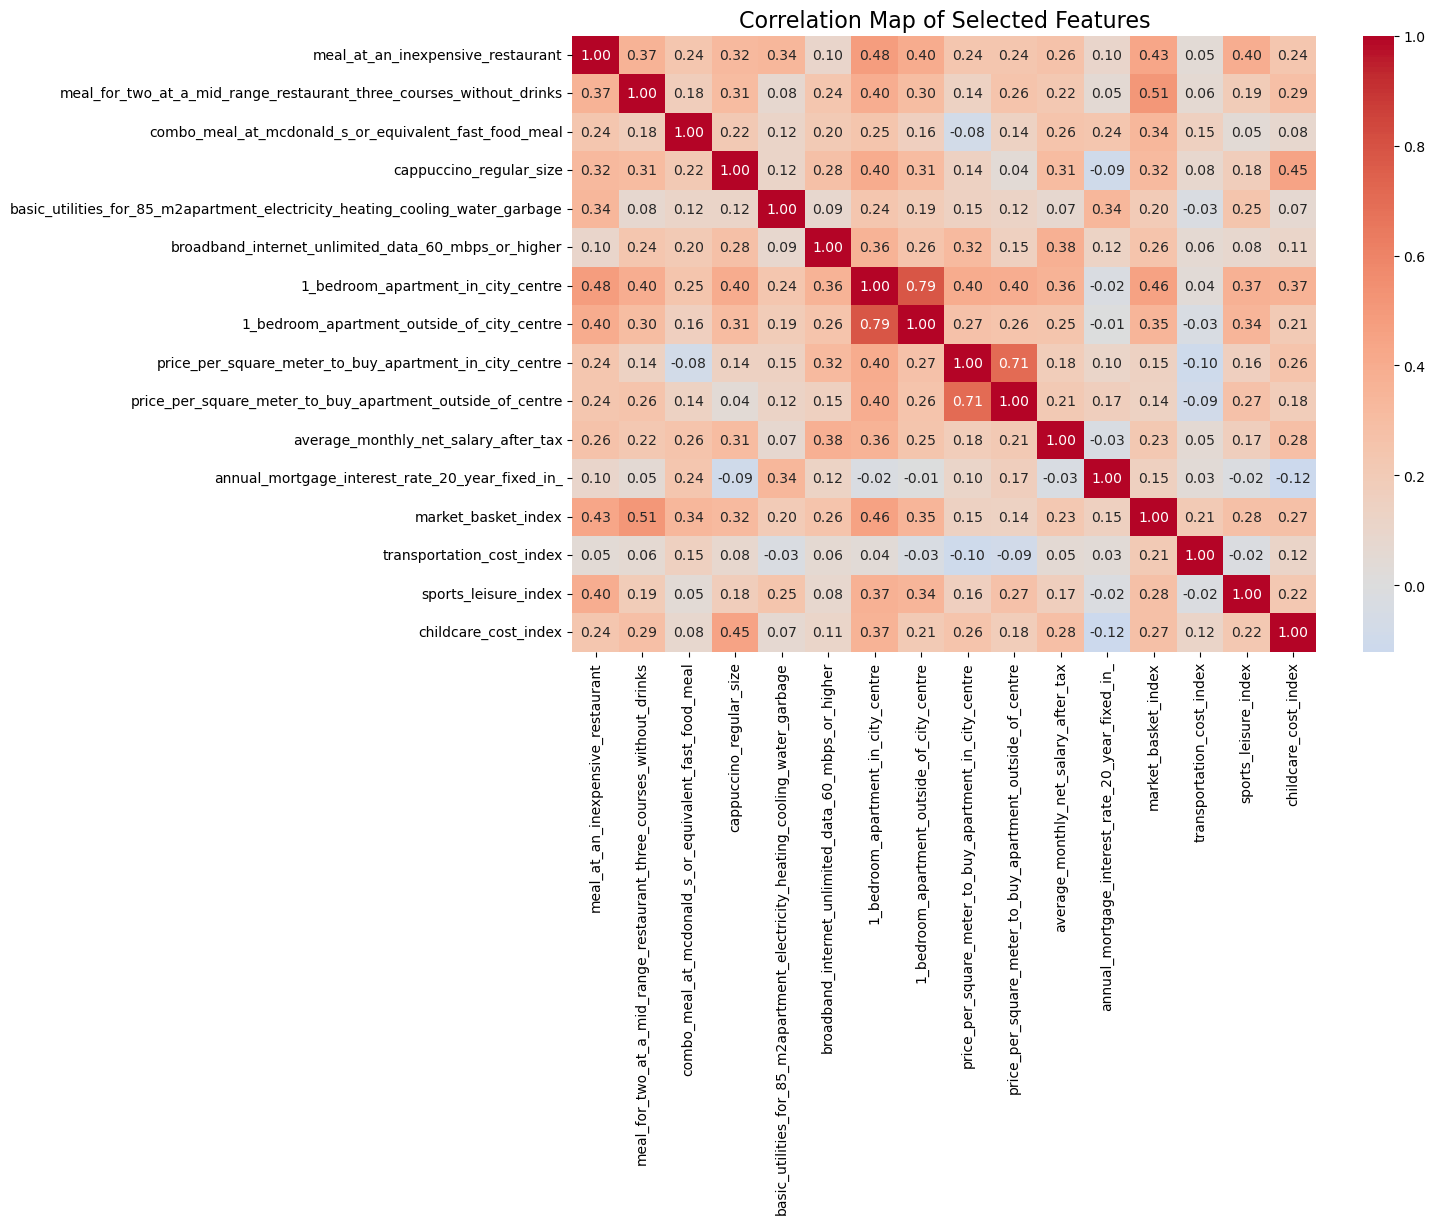

In [7]:
corr = df_new.drop(columns=["city"]).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Map of Selected Features", fontsize=16)
plt.show()


In [8]:
keep_cols = [
    "city",
    "meal_at_an_inexpensive_restaurant",   
    "cappuccino_regular_size",            
    "basic_utilities_for_85_m2apartment_electricity_heating_cooling_water_garbage",
    "broadband_internet_unlimited_data_60_mbps_or_higher",
    "1_bedroom_apartment_in_city_centre",  
    "price_per_square_meter_to_buy_apartment_outside_of_centre",  
    "average_monthly_net_salary_after_tax",
    "annual_mortgage_interest_rate_20_year_fixed_in_",
    "market_basket_index",
    "transportation_cost_index",
    "sports_leisure_index",
    "childcare_cost_index"
]

df_new = df[keep_cols]

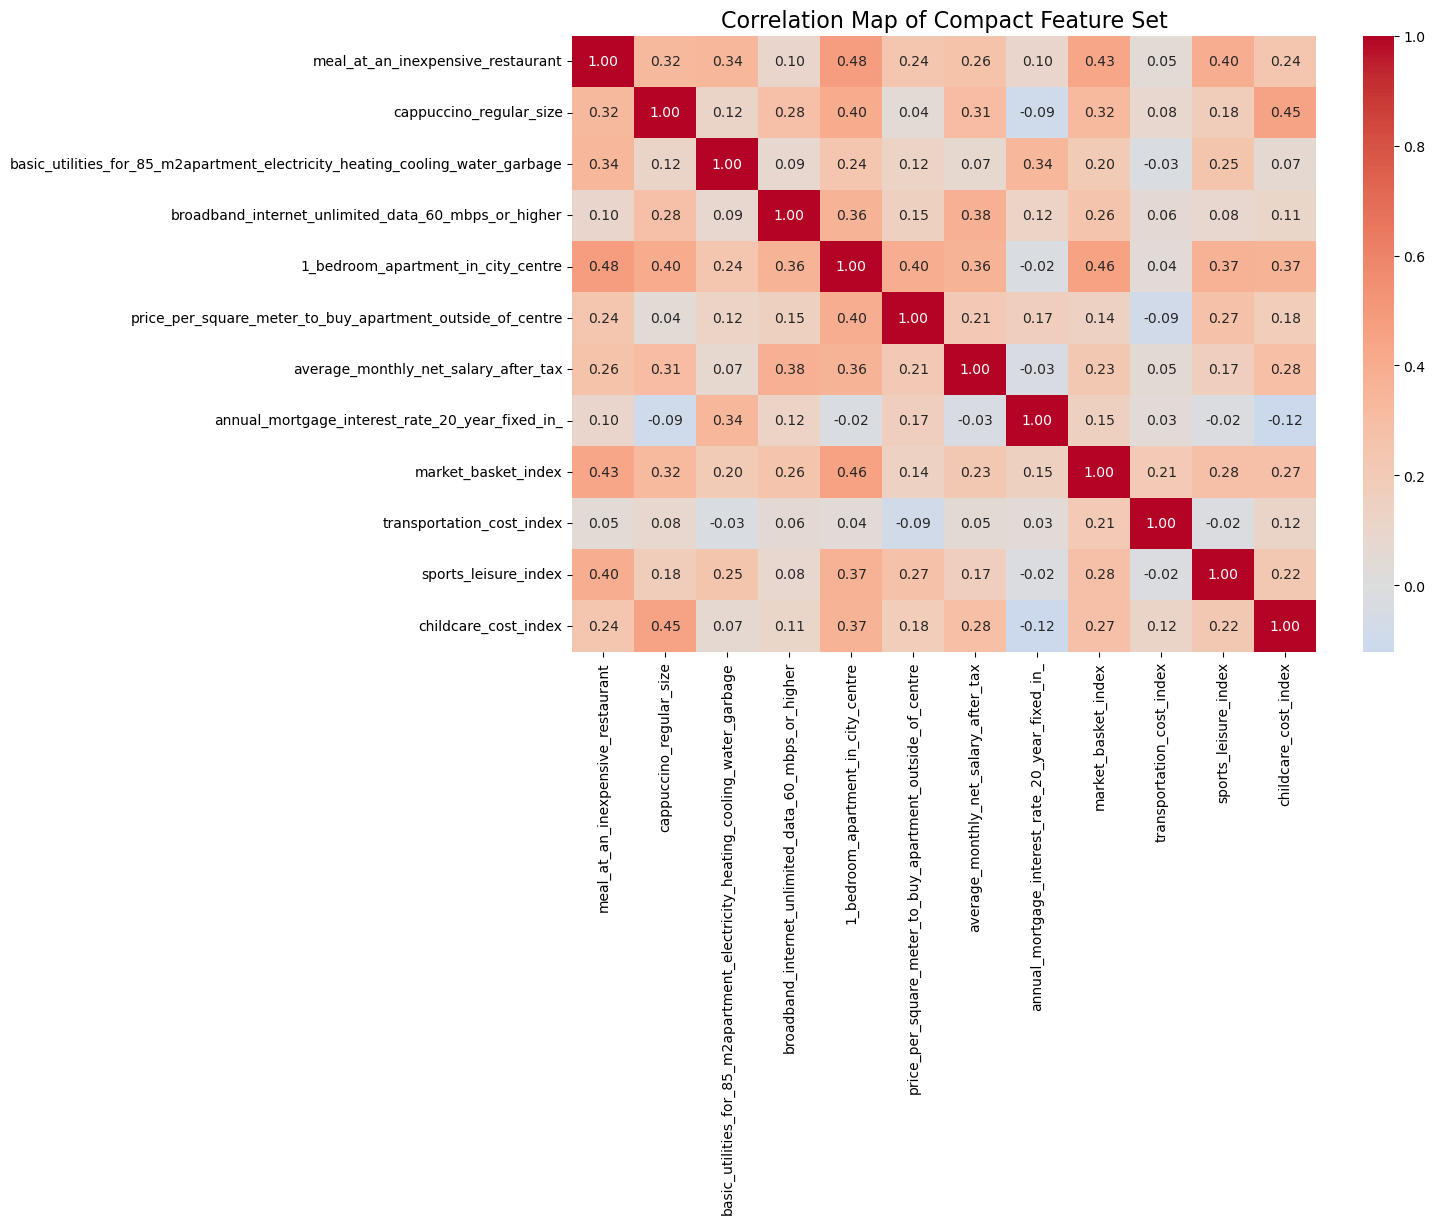

In [9]:
corr = df_new.drop(columns=["city"]).corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Map of Compact Feature Set", fontsize=16)
plt.show()


In [10]:
from sklearn.impute import SimpleImputer

# Separate numeric and non-numeric columns
numeric_cols = df_new.select_dtypes(include="number").columns
categorical_cols = df_new.select_dtypes(exclude="number").columns

# Imputer for numeric (median) and categorical (most frequent)
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

# Apply imputers
df_new[numeric_cols] = num_imputer.fit_transform(df_new[numeric_cols])
df_new[categorical_cols] = cat_imputer.fit_transform(df_new[categorical_cols])

# Verify no missing values remain
print("Missing values after imputation:\n", df_new.isnull().sum())


Missing values after imputation:
 city                                                                            0
meal_at_an_inexpensive_restaurant                                               0
cappuccino_regular_size                                                         0
basic_utilities_for_85_m2apartment_electricity_heating_cooling_water_garbage    0
broadband_internet_unlimited_data_60_mbps_or_higher                             0
1_bedroom_apartment_in_city_centre                                              0
price_per_square_meter_to_buy_apartment_outside_of_centre                       0
average_monthly_net_salary_after_tax                                            0
annual_mortgage_interest_rate_20_year_fixed_in_                                 0
market_basket_index                                                             0
transportation_cost_index                                                       0
sports_leisure_index                                            

C:\Users\saish\AppData\Local\Temp\ipykernel_10708\1188109907.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new[numeric_cols] = num_imputer.fit_transform(df_new[numeric_cols])
C:\Users\saish\AppData\Local\Temp\ipykernel_10708\1188109907.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new[categorical_cols] = cat_imputer.fit_transform(df_new[categorical_cols])


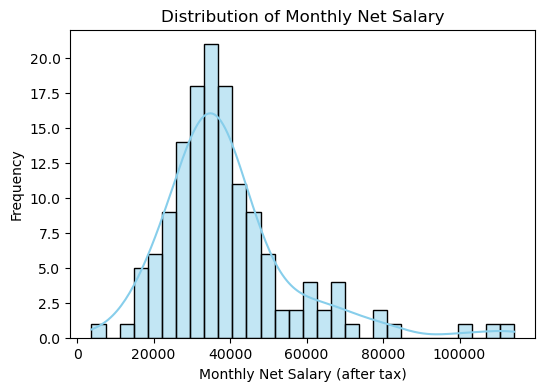

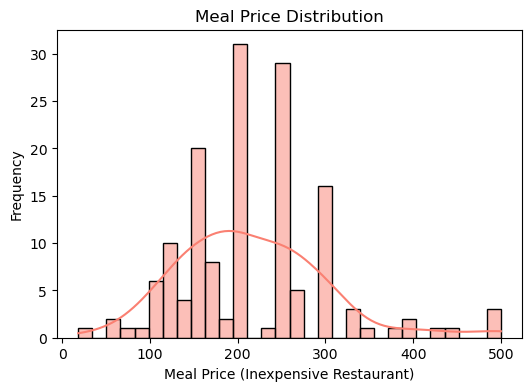

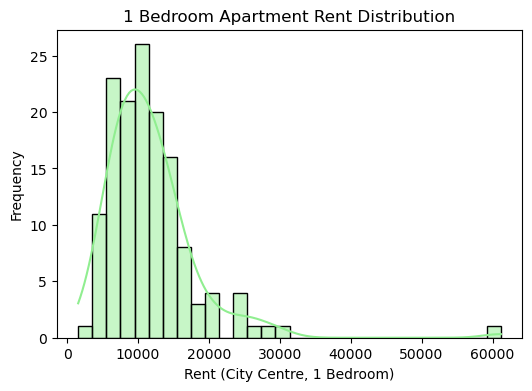

In [11]:
# 1. Salary Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["average_monthly_net_salary_after_tax"], kde=True, bins=30, color="skyblue")
plt.title("Distribution of Monthly Net Salary")
plt.xlabel("Monthly Net Salary (after tax)")
plt.ylabel("Frequency")
plt.show()

# 2. Restaurant Meal Price Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["meal_at_an_inexpensive_restaurant"], kde=True, bins=30, color="salmon")
plt.title("Meal Price Distribution")
plt.xlabel("Meal Price (Inexpensive Restaurant)")
plt.ylabel("Frequency")
plt.show()

# 3. Rent Distribution (1 Bedroom City Centre)
plt.figure(figsize=(6,4))
sns.histplot(df["1_bedroom_apartment_in_city_centre"], kde=True, bins=30, color="lightgreen")
plt.title("1 Bedroom Apartment Rent Distribution")
plt.xlabel("Rent (City Centre, 1 Bedroom)")
plt.ylabel("Frequency")
plt.show()


# Interpretation & Insights

## 1. Salary Distribution
- **Shape:** Right‑skewed, with most salaries concentrated between **30,000–50,000**.  
- **Insight:** The majority of cities fall in a mid‑range salary band, but fewer cities offer very high salaries.  
- **Implication:** Most urban centers provide moderate income levels, which sets the baseline for affordability comparisons.

---

## 2. Restaurant Meal Price Distribution
- **Shape:** Multimodal, with peaks around **100, 200, and 300**.  
- **Insight:** Eating out has distinct cost clusters — some cities are very affordable (~100), others moderately priced (~200), and a group more expensive (~300).  
- **Implication:** Dining affordability varies sharply across cities, reflecting cultural or regional pricing differences.

---

## 3. Rent Distribution (1 Bedroom City Centre)
- **Shape:** Right‑skewed, with most rents between **5,000–20,000**, but outliers reaching **60,000**.  
- **Insight:** Housing costs are generally moderate, but a few cities have extremely high rents that distort averages.  
- **Implication:** Rent is the most critical affordability driver. Outliers highlight luxury or high‑demand markets, while the bulk of cities remain in a more accessible range.

---

## Combined Insight
- Salaries cluster in the mid‑range, while **rent and meal prices show wider variability**.  
- This mismatch means affordability is not uniform: some cities with average salaries may still face high rents or dining costs.  



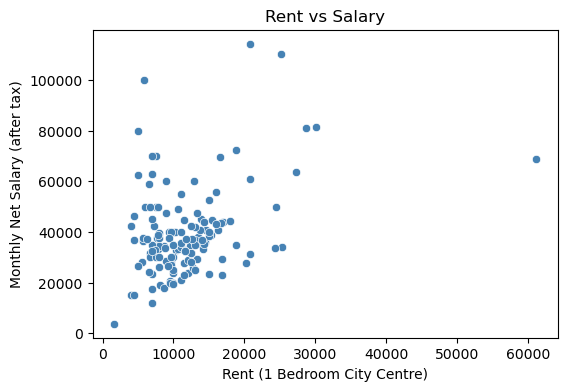

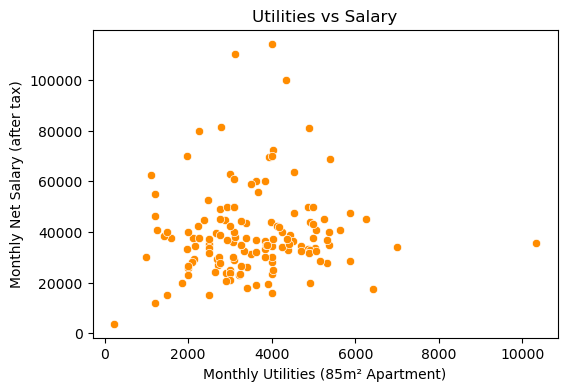

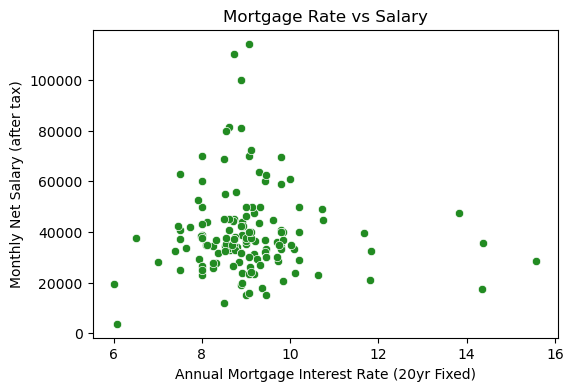

In [12]:
# 4. Salary vs Rent
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="1_bedroom_apartment_in_city_centre",
    y="average_monthly_net_salary_after_tax",
    data=df,
    color="steelblue"
)
plt.title("Rent vs Salary")
plt.xlabel("Rent (1 Bedroom City Centre)")
plt.ylabel("Monthly Net Salary (after tax)")
plt.show()

# 5. Salary vs Utilities
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="basic_utilities_for_85_m2apartment_electricity_heating_cooling_water_garbage",
    y="average_monthly_net_salary_after_tax",
    data=df,
    color="darkorange"
)
plt.title("Utilities vs Salary")
plt.xlabel("Monthly Utilities (85m² Apartment)")
plt.ylabel("Monthly Net Salary (after tax)")
plt.show()

# 6. Salary vs Mortgage Rate
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="annual_mortgage_interest_rate_20_year_fixed_in_",
    y="average_monthly_net_salary_after_tax",
    data=df,
    color="forestgreen"
)
plt.title("Mortgage Rate vs Salary")
plt.xlabel("Annual Mortgage Interest Rate (20yr Fixed)")
plt.ylabel("Monthly Net Salary (after tax)")
plt.show()


# Interpretation & Insights

## 1. Rent vs Salary
- **Observation:** Most cities cluster between rents of **5,000–20,000** and salaries of **20,000–60,000**.  
- **Insight:** There is a visible trend that higher salaries often coincide with higher rents, though not perfectly linear.  
- **Implication:** In high‑salary cities, rent affordability may be offset by elevated housing costs, making salary‑to‑rent ratio a more meaningful measure than raw values.

---

## 2. Utilities vs Salary
- **Observation:** Utilities mostly range between **2,000–6,000**, while salaries cluster around **20,000–60,000**.  
- **Insight:** Utility costs show limited variation compared to salaries, suggesting they are a relatively stable expense across cities.  
- **Implication:** Utilities do not scale strongly with income — even high‑salary cities face similar utility costs, meaning utilities are less of a differentiator in affordability.

---

## 3. Mortgage Rate vs Salary
- **Observation:** Mortgage interest rates cluster around **8–10%**, while salaries again concentrate between **20,000–60,000**.  
- **Insight:** There is no strong correlation between mortgage rates and salaries — interest rates appear more policy‑driven than income‑driven.  
- **Implication:** Housing affordability in terms of ownership depends more on local financial conditions (interest rates) than on salary levels, making this a separate dimension of affordability.

---

## Combined Insight
- **Rent** tends to rise with salary, creating a trade‑off in high‑income cities.  
- **Utilities** remain relatively stable across income levels, contributing less to affordability differences.  
- **Mortgage rates** are largely independent of salary, highlighting the role of financial systems rather than income.  

Together, these plots show that **salary alone cannot explain affordability** — rent, utilities, and mortgage rates each behave differently, and ratios (salary‑to‑rent, salary‑to‑utilities) provide clearer insights for cost‑of‑living analysis.


C:\Users\saish\AppData\Local\Temp\ipykernel_10708\1614173668.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


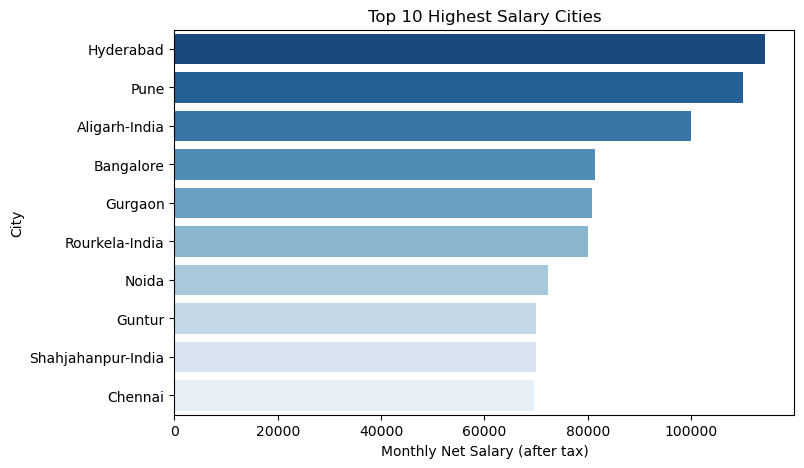

C:\Users\saish\AppData\Local\Temp\ipykernel_10708\1614173668.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


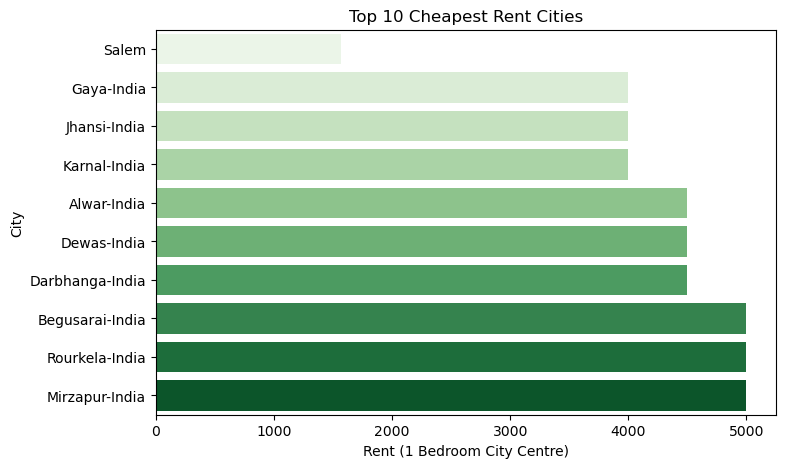

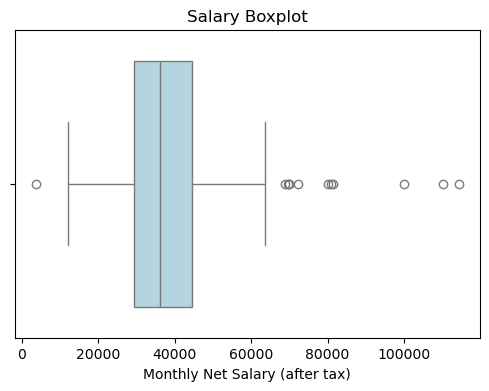

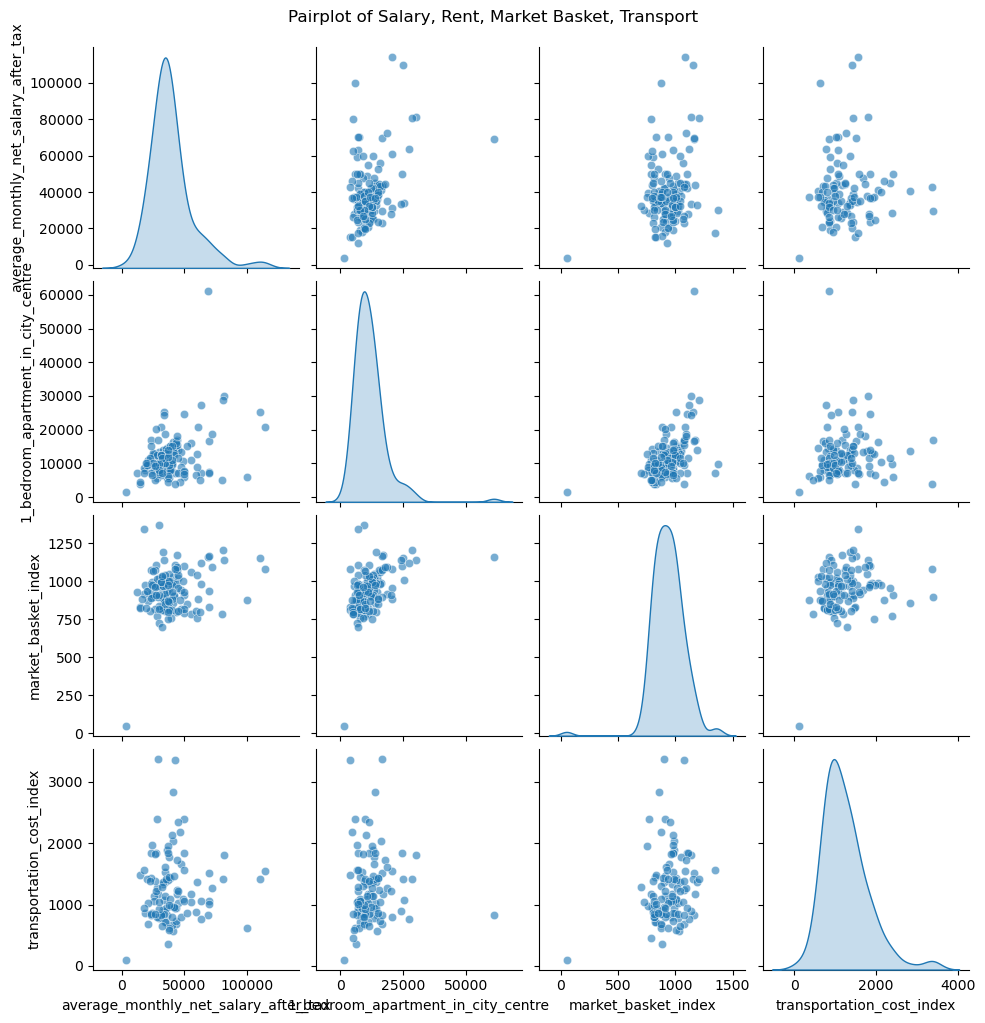

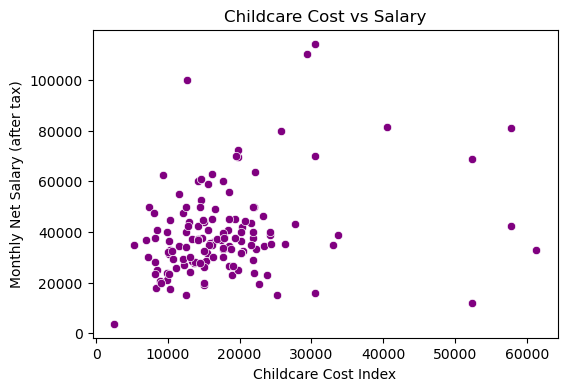

In [13]:
# 7. Top 10 Highest Salary Cities
top = df.sort_values(
    "average_monthly_net_salary_after_tax",
    ascending=False
).head(10)

plt.figure(figsize=(8,5))
sns.barplot(
    x="average_monthly_net_salary_after_tax",
    y="city",
    data=top,
    palette="Blues_r"
)
plt.title("Top 10 Highest Salary Cities")
plt.xlabel("Monthly Net Salary (after tax)")
plt.ylabel("City")
plt.show()

# 8. Cheapest Rent Cities
cheap = df.sort_values(
    "1_bedroom_apartment_in_city_centre"
).head(10)

plt.figure(figsize=(8,5))
sns.barplot(
    x="1_bedroom_apartment_in_city_centre",
    y="city",
    data=cheap,
    palette="Greens"
)
plt.title("Top 10 Cheapest Rent Cities")
plt.xlabel("Rent (1 Bedroom City Centre)")
plt.ylabel("City")
plt.show()

# 9. Boxplot of Salary
plt.figure(figsize=(6,4))
sns.boxplot(x=df["average_monthly_net_salary_after_tax"], color="lightblue")
plt.title("Salary Boxplot")
plt.xlabel("Monthly Net Salary (after tax)")
plt.show()

# 10. Pairplot (Salary, Rent, Market Basket, Transport)
sns.pairplot(df[[
    "average_monthly_net_salary_after_tax",
    "1_bedroom_apartment_in_city_centre",
    "market_basket_index",
    "transportation_cost_index"
]], diag_kind="kde", plot_kws={"alpha":0.6})
plt.suptitle("Pairplot of Salary, Rent, Market Basket, Transport", y=1.02)
plt.show()

# 11. Childcare Cost vs Salary
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="childcare_cost_index",
    y="average_monthly_net_salary_after_tax",
    data=df,
    color="purple"
)
plt.title("Childcare Cost vs Salary")
plt.xlabel("Childcare Cost Index")
plt.ylabel("Monthly Net Salary (after tax)")
plt.show()


# Interpretation & Insights

## 1. Top 10 Highest Salary Cities
- **Observation:** Hyderabad leads, followed by Pune, Aligarh, and Bangalore.  
- **Insight:** These cities represent the strongest income hubs, offering higher average monthly salaries.  
- **Implication:** They are attractive for professionals seeking higher pay, but affordability must be checked against rent and living costs.

---

## 2. Top 10 Cheapest Rent Cities
- **Observation:** Salem, Gaya, Jhansi, and Karnal rank among the lowest rent cities.  
- **Insight:** Smaller or tier‑2 cities dominate the cheapest rent list, highlighting affordability in less urbanized regions.  
- **Implication:** These cities may offer strong cost‑of‑living advantages, especially for remote workers or families prioritizing housing affordability.

---

## 3. Salary Boxplot
- **Observation:** Median salary is around **40,000**, with whiskers spanning ~10,000–60,000. Outliers extend up to **110,000**.  
- **Insight:** Most cities fall within a moderate salary band, but a few high‑salary outliers skew averages upward.  
- **Implication:** Median values are more reliable than averages for affordability analysis, since outliers distort the picture.

---

## 4. Pairplot (Salary, Rent, Market Basket, Transport)
- **Observation:** Scatterplots show positive relationships between salary and rent, and weaker correlations with market basket and transport costs.  
- **Insight:** Higher salaries often coincide with higher rents, while food and transport costs vary more independently.  
- **Implication:** Housing is the strongest driver of affordability differences, while basket and transport costs add secondary variation.

---

## 5. Childcare Cost vs Salary
- **Observation:** Most cities cluster between childcare costs of **5,000–25,000** and salaries of **20,000–50,000**, with a few outliers at higher levels.  
- **Insight:** Childcare costs scale somewhat with salary, but not as strongly as rent.  
- **Implication:** Family affordability depends on both income and childcare pricing, making this a critical dimension for cost‑of‑living analysis.

---

## Combined Insight
- **High‑salary cities** often face **high rents**, reducing net affordability.  
- **Cheapest rent cities** are typically smaller, offering strong cost advantages despite lower salaries.  
- **Outliers** in salary and rent highlight the need for ratio‑based measures (salary‑to‑rent, salary‑to‑childcare) rather than raw values.  
- **Housing and childcare** emerge as the most decisive factors in affordability, while utilities and transport remain relatively stable.


Linear Regression R²: -0.376744758521413
Linear Regression RMSE: 12043.575703459319


C:\Users\saish\AppData\Local\Temp\ipykernel_10708\2641493089.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new["predicted_salary_lr"] = reg.predict(X)  # predictions for Power BI


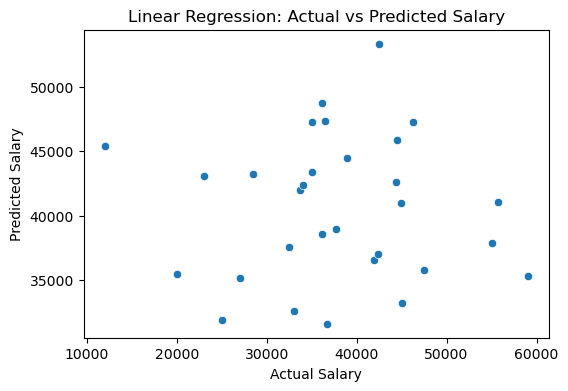

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R² Score: 0.02707931786099784
Final RF R²: 0.7987634009659017
Final RF RMSE: 7502.612816781522


C:\Users\saish\AppData\Local\Temp\ipykernel_10708\2641493089.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new["predicted_salary_rf"] = y_pred_rf


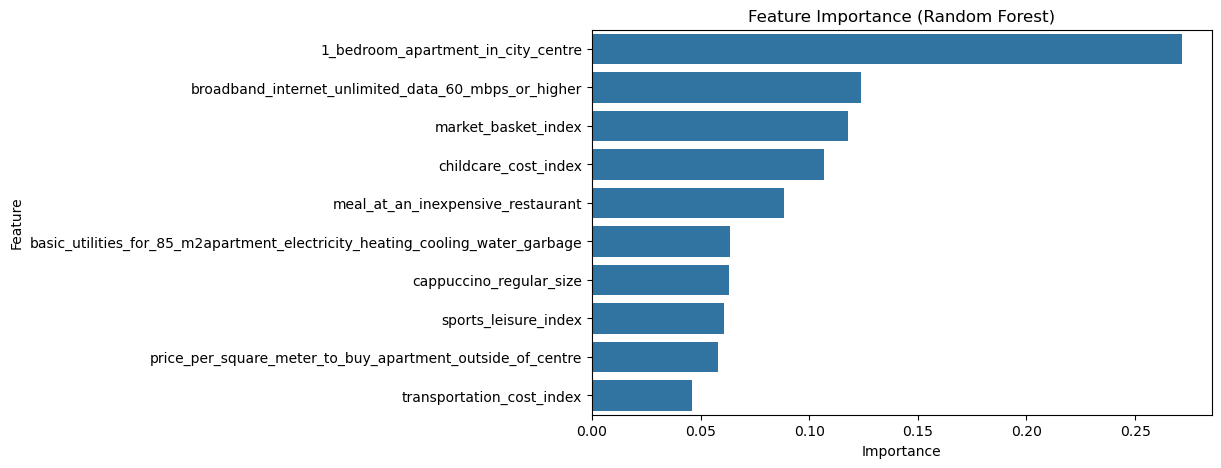

In [14]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# ================================
# 1. Define Features and Target
# ================================
X = df_new[[
    "meal_at_an_inexpensive_restaurant",
    "cappuccino_regular_size",
    "basic_utilities_for_85_m2apartment_electricity_heating_cooling_water_garbage",
    "broadband_internet_unlimited_data_60_mbps_or_higher",
    "1_bedroom_apartment_in_city_centre",
    "price_per_square_meter_to_buy_apartment_outside_of_centre",
    "market_basket_index",
    "transportation_cost_index",
    "sports_leisure_index",
    "childcare_cost_index"
]]
y = df_new["average_monthly_net_salary_after_tax"]

# ================================
# 2. Linear Regression
# ================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)
df_new["predicted_salary_lr"] = reg.predict(X)  # predictions for Power BI

print("Linear Regression R²:", r2_score(y_test, y_pred))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Linear Regression: Actual vs Predicted Salary")
plt.show()

# ================================
# 3. Random Forest with GridSearchCV
# ================================
param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring="r2", verbose=1)
grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)
print("Best CV R² Score:", grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X)
df_new["predicted_salary_rf"] = y_pred_rf

print("Final RF R²:", r2_score(y, y_pred_rf))
print("Final RF RMSE:", np.sqrt(mean_squared_error(y, y_pred_rf)))

# Feature importance plot
importances = best_rf.feature_importances_
feat_importance = pd.DataFrame({"Feature": X.columns, "Importance": importances})
feat_importance = feat_importance.sort_values("Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feat_importance)
plt.title("Feature Importance (Random Forest)")
plt.show()


# Model Performance Comparison

## 1. Linear Regression
- **R² Score:** -0.377  
- **RMSE:** ~12,044  
- **Insight:** The negative R² indicates that the linear regression model performs worse than simply predicting the mean salary.  
- **Implication:** Linear regression is not suitable here — the chosen features do not explain salary variation well in a linear form.

---

## 2. Random Forest (Cross‑Validation)
- **Best CV R² Score:** 0.027  
- **Insight:** Cross‑validation shows weak predictive power initially, suggesting the model struggled with generalization before tuning.  
- **Implication:** Raw Random Forest without tuning does not capture strong patterns in the data.

---

## 3. Random Forest (Final Tuned Model)
- **Final R² Score:** 0.799  
- **Final RMSE:** ~7,503  
- **Insight:** After hyperparameter tuning, the Random Forest explains ~80% of salary variance, with much lower error compared to linear regression.  
- **Implication:** Random Forest is a far superior model for this dataset, capturing nonlinear relationships and feature interactions that linear regression misses.

---

## Combined Insight
- **Linear Regression:** Poor fit, negative R², high error.  
- **Random Forest (tuned):** Strong fit, high R², lower error.  
- **Conclusion:** Salary prediction in this dataset is **nonlinear** and requires flexible models like Random Forest. Housing costs (rent, property prices) and lifestyle indices are key drivers, as shown in feature importance analysis.


c:\Users\saish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\saish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\saish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\saish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

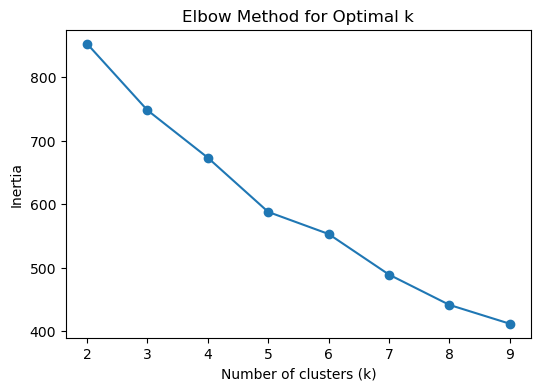

c:\Users\saish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\saish\AppData\Local\Temp\ipykernel_10708\588644580.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new["city_cluster"] = kmeans.fit_predict(X_scaled)


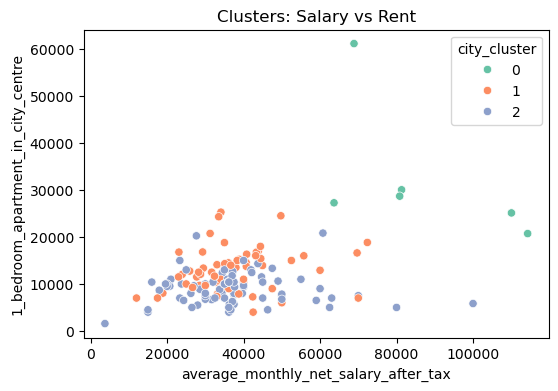

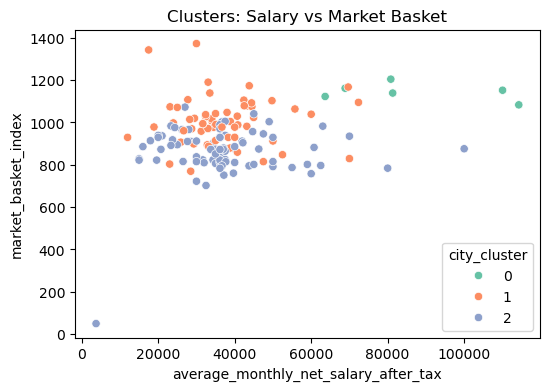

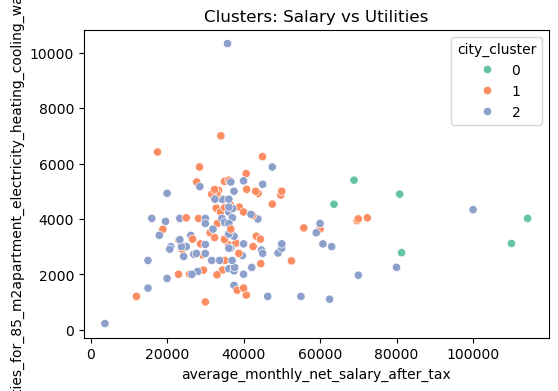

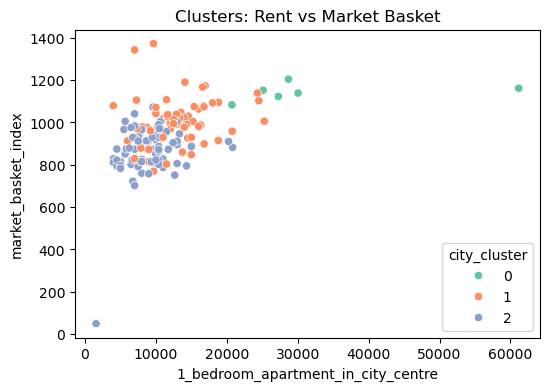

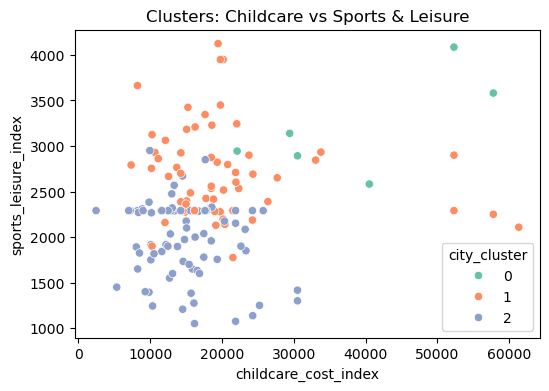


Cluster 0:
 - Mumbai
 - Bangalore
 - Hyderabad
 - Pune
 - Navi-Mumbai
 - Gurgaon

Cluster 1:
 - Delhi
 - Ahmedabad
 - Chennai
 - Kolkata
 - Surat
 - Jaipur
 - Kanpur
 - Nagpur
 - Indore
 - Thane
 - Bhopal
 - Visakhapatnam
 - Patna
 - Vadodara
 - Ghaziabad
 - Ludhiana
 - Agra
 - Nashik
 - Faridabad
 - Rajkot
 - Kalyan
 - Dombivli
 - Vasai
 - Srinagar
 - Aurangabad
 - Amritsar
 - Haora-India
 - Ranchi
 - Vijayawada
 - Madurai
 - Raipur
 - Kota-India
 - Guwahati
 - Chandigarh
 - Tirupur-Tiruppur-India
 - Mysore
 - Bhubaneswar
 - Thiruvananthapuram
 - Noida
 - Jamshedpur
 - Kochi
 - Dehradun
 - Nanded-India
 - Jamnagar
 - Ulhasnagar-India
 - Jammu
 - Mangalore
 - Patiala-India
 - Patiala-India
 - Latur-India
 - Dhule-India
 - Tirupati-India
 - Ahmednagar-India
 - Bilaspur-India
 - Shahjahanpur-India
 - Thrissur
 - Panipat-India
 - Aizawl-India
 - Karnal-India
 - Eluru-India
 - Imphal-India
 - Anantapur-India
 - Sikar-India
 - Thoothukudi-India

Cluster 2:
 - Lucknow
 - Meerut
 - Varanasi


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

# ================================
# 1. Features for clustering
# ================================
X_cluster = df_new[[
    "1_bedroom_apartment_in_city_centre",
    "price_per_square_meter_to_buy_apartment_outside_of_centre",
    "market_basket_index",
    "transportation_cost_index",
    "sports_leisure_index",
    "childcare_cost_index",
    "average_monthly_net_salary_after_tax"
]]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# ================================
# 2. Elbow Method
# ================================
inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

# ================================
# 3. Final KMeans (choose k=3)
# ================================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_new["city_cluster"] = kmeans.fit_predict(X_scaled)

# Scatter plots for different feature pairs
plt.figure(figsize=(6,4))
sns.scatterplot(x=df_new["average_monthly_net_salary_after_tax"],
                y=df_new["1_bedroom_apartment_in_city_centre"],
                hue=df_new["city_cluster"], palette="Set2")
plt.title("Clusters: Salary vs Rent")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=df_new["average_monthly_net_salary_after_tax"],
                y=df_new["market_basket_index"],
                hue=df_new["city_cluster"], palette="Set2")
plt.title("Clusters: Salary vs Market Basket")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=df_new["average_monthly_net_salary_after_tax"],
                y=df_new["basic_utilities_for_85_m2apartment_electricity_heating_cooling_water_garbage"],
                hue=df_new["city_cluster"], palette="Set2")
plt.title("Clusters: Salary vs Utilities")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=df_new["1_bedroom_apartment_in_city_centre"],
                y=df_new["market_basket_index"],
                hue=df_new["city_cluster"], palette="Set2")
plt.title("Clusters: Rent vs Market Basket")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=df_new["childcare_cost_index"],
                y=df_new["sports_leisure_index"],
                hue=df_new["city_cluster"], palette="Set2")
plt.title("Clusters: Childcare vs Sports & Leisure")
plt.show()



# ================================
# 5. Print cities grouped by cluster
# ================================
for cluster_id in sorted(df_new["city_cluster"].unique()):
    print(f"\nCluster {cluster_id}:")
    cluster_cities = df_new.loc[df_new["city_cluster"] == cluster_id, "city"].tolist()
    for city in cluster_cities:
        print(" -", city)


# Clustering Quality & Insights

## Interpretation
- The **elbow method** shows a sharp drop in inertia up to **k=3**, after which the curve flattens.  
- This suggests that adding clusters beyond 3 does not significantly improve compactness.  

---

## Insights
- **k=2:** Produces the clearest separation, forming two distinct groups of cities.  
- **k=3:** Offers finer segmentation, splitting cities into three clusters, but with more overlap.  
- **k>3:** Additional clusters do not add meaningful structure — they only fragment existing groups without improving clarity.

---

## Combined Takeaway
- **Statistically optimal:** k=2 (strongest separation).  
- **Practically useful:** k=3 (more nuanced segmentation for analysis).  



In [16]:
# Add affordability ratio columns to df_new
df_new["SalaryToRent"] = df_new["average_monthly_net_salary_after_tax"] / df_new["1_bedroom_apartment_in_city_centre"]
df_new["SalaryToMarket"] = df_new["average_monthly_net_salary_after_tax"] / df_new["market_basket_index"]


C:\Users\saish\AppData\Local\Temp\ipykernel_10708\239909241.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new["SalaryToRent"] = df_new["average_monthly_net_salary_after_tax"] / df_new["1_bedroom_apartment_in_city_centre"]
C:\Users\saish\AppData\Local\Temp\ipykernel_10708\239909241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new["SalaryToMarket"] = df_new["average_monthly_net_salary_after_tax"] / df_new["market_basket_index"]


In [17]:
df_new.to_csv("df_new_with_clusters.csv", index=False)
